In [2]:
import torch
import numpy as np

In [3]:
a = [1,2,3]
b = np.array([1,2,3], dtype=np.int32)

t_a = torch.tensor(a)
t_b = torch.from_numpy(b)

print(t_a)
print(t_b)

tensor([1, 2, 3])
tensor([1, 2, 3], dtype=torch.int32)


In [4]:
t_ones = torch.ones(2,3)
t_ones.shape

torch.Size([2, 3])

In [5]:
#manipulate tensors
t = torch.rand(2,3)
t_tr = t.transpose(0,1)
print(t.shape, '->', t_tr.shape)

t = torch.zeros(30)
t_reshape = t.reshape(5,6)
print(t_reshape.shape)



torch.Size([2, 3]) -> torch.Size([3, 2])
torch.Size([5, 6])


In [6]:
t = torch.zeros(1, 2, 1, 4, 1)
t_squeeze = t.squeeze(2)
print(t.shape, '->', t_squeeze.shape)

torch.Size([1, 2, 1, 4, 1]) -> torch.Size([1, 2, 4, 1])


In [7]:
# element-wise operations
torch.manual_seed(1)
t1 = 2 * torch.rand(5, 2) - 1
t2 = torch.normal(mean=0, std=1, size=(5, 2))

t3 = torch.multiply(t1, t2)
print(t3)

tensor([[ 0.4426, -0.3114],
        [ 0.0660, -0.5970],
        [ 1.1249,  0.0150],
        [ 0.1569,  0.7107],
        [-0.0451, -0.0352]])


In [8]:
#matrix multiplication
t5 = torch.matmul(t1, t2.transpose(0,1))
t5

tensor([[ 0.1312,  0.3860, -0.6267, -1.0096, -0.2943],
        [ 0.1647, -0.5310,  0.2434,  0.8035,  0.1980],
        [-0.3855, -0.4422,  1.1399,  1.5558,  0.4781],
        [ 0.1822, -0.5771,  0.2585,  0.8676,  0.2132],
        [ 0.0330,  0.1084, -0.1692, -0.2771, -0.0804]])

In [9]:
# calculate L^p norm of linear algebra operations

from torch._dynamo.utils import T7


t6 = torch.linalg.norm(t1, ord=2, dim=1)
print(t6)

t7 = np.sqrt(np.sum(np.square(t1.numpy()), axis=1))
print(t7)

tensor([0.6785, 0.5078, 1.1162, 0.5488, 0.1853])
[0.67846215 0.5078282  1.1162277  0.5487652  0.18525197]


In [10]:
# concatennation

A = torch.ones(3)
B = torch.zeros(2)

print(A.shape)
print(B.shape)
C = torch.concat((A, B), axis=0)
print(C)

torch.Size([3])
torch.Size([2])
tensor([1., 1., 1., 0., 0.])


In [11]:
from torch.utils.data import DataLoader

t = torch.arange(6, dtype=torch.float32)
data_loader = DataLoader(t, batch_size=3, drop_last=False)

for idx, item in enumerate(data_loader):
    print(item)

tensor([0., 1., 2.])
tensor([3., 4., 5.])


In [12]:
# joint dataset
from torch.utils.data import Dataset

X = torch.randn(100, 2)
y = np.arange(100)

class JointDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [13]:
joint_dataset = JointDataset(X, y)

for item in joint_dataset:
    print("X: ", item[0], " y: ", item[1])

X:  tensor([ 1.8793, -0.0721])  y:  0
X:  tensor([ 0.1578, -0.7735])  y:  1
X:  tensor([0.1991, 0.0457])  y:  2
X:  tensor([ 0.1530, -0.4757])  y:  3
X:  tensor([-0.1110,  0.2927])  y:  4
X:  tensor([-0.1578, -0.0288])  y:  5
X:  tensor([ 2.3571, -1.0373])  y:  6
X:  tensor([ 1.5748, -0.6298])  y:  7
X:  tensor([-0.9274,  0.5451])  y:  8
X:  tensor([ 0.0663, -0.4370])  y:  9
X:  tensor([0.7626, 0.4415])  y:  10
X:  tensor([1.1651, 2.0154])  y:  11
X:  tensor([0.1374, 0.9386])  y:  12
X:  tensor([-0.1860, -0.6446])  y:  13
X:  tensor([ 1.5392, -0.8696])  y:  14
X:  tensor([-3.3312, -0.7479])  y:  15
X:  tensor([-0.0255, -1.0233])  y:  16
X:  tensor([-0.5962, -1.0055])  y:  17
X:  tensor([-0.2106, -0.0075])  y:  18
X:  tensor([1.6734, 0.0103])  y:  19
X:  tensor([-0.7040, -0.1853])  y:  20
X:  tensor([-0.9962, -0.8313])  y:  21
X:  tensor([-0.4610, -0.5601])  y:  22
X:  tensor([ 0.3956, -0.9823])  y:  23
X:  tensor([-0.5065,  0.0998])  y:  24
X:  tensor([-0.6540,  0.7317])  y:  25
X:  te

In [14]:
data_loader = DataLoader(joint_dataset, batch_size=3, shuffle=True)

In [15]:
for i, batch in enumerate(data_loader, 1):
    print(f'batch {i}:', 'x:', batch[0],
'\n y:', batch[1])

batch 1: x: tensor([[-1.4782, -1.1334],
        [-0.5962, -1.0055],
        [ 0.8437,  1.1657]]) 
 y: tensor([39, 17, 72])
batch 2: x: tensor([[0.6614, 1.1899],
        [1.5113, 0.6419],
        [1.3352, 0.6043]]) 
 y: tensor([32, 57, 36])
batch 3: x: tensor([[-0.3417,  0.9473],
        [-0.9962, -0.8313],
        [-0.2106, -0.0075]]) 
 y: tensor([79, 21, 18])
batch 4: x: tensor([[ 0.2389,  1.3440],
        [ 1.7460,  1.8550],
        [-0.0135,  1.8606]]) 
 y: tensor([77, 62, 45])
batch 5: x: tensor([[-0.8400, -0.4200],
        [ 1.3851, -0.8138],
        [-0.2076, -1.3889]]) 
 y: tensor([65, 34, 93])
batch 6: x: tensor([[1.7997, 0.2824],
        [0.7626, 0.4415],
        [0.3437, 0.3718]]) 
 y: tensor([95, 10, 99])
batch 7: x: tensor([[-0.9640,  0.1415],
        [ 0.1716, -0.1600],
        [ 1.6604,  0.2717]]) 
 y: tensor([74, 27, 96])
batch 8: x: tensor([[ 1.7223, -0.3036],
        [ 1.7837, -0.1954],
        [-0.6240, -0.9773]]) 
 y: tensor([76, 81, 66])
batch 9: x: tensor([[ 0.1374

In [16]:
for epoch in range(2):
    print(f'epoch {epoch+1}')
    for i, batch in enumerate(data_loader, 1):
        print(f'batch {i}:', 'x:', batch[0],
'\n y:', batch[1])

epoch 1
batch 1: x: tensor([[-0.2076, -1.3889],
        [ 0.2389,  1.3440],
        [-1.3633, -0.9832]]) 
 y: tensor([93, 77, 56])
batch 2: x: tensor([[-0.5206,  1.3548],
        [ 0.7124, -1.7765],
        [ 0.2692,  1.3248]]) 
 y: tensor([89, 48, 61])
batch 3: x: tensor([[-0.9276,  1.1120],
        [ 0.1578, -0.7735],
        [ 0.5514, -1.5474]]) 
 y: tensor([35,  1, 59])
batch 4: x: tensor([[ 1.5748, -0.6298],
        [ 0.0127, -1.8734],
        [ 1.6734,  0.0103]]) 
 y: tensor([ 7, 94, 19])
batch 5: x: tensor([[ 1.6604,  0.2717],
        [ 0.5431,  0.6607],
        [-0.1578, -0.0288]]) 
 y: tensor([96, 53,  5])
batch 6: x: tensor([[ 0.1991,  0.0457],
        [ 0.3437,  0.3718],
        [-1.0412,  0.7323]]) 
 y: tensor([ 2, 99, 29])
batch 7: x: tensor([[-0.8825,  0.5318],
        [ 0.2352,  1.9142],
        [-3.3312, -0.7479]]) 
 y: tensor([85, 90, 15])
batch 8: x: tensor([[ 1.2858,  0.8168],
        [ 2.2952,  0.6749],
        [-0.0135,  1.8606]]) 
 y: tensor([41, 54, 45])
batch 9:

In [17]:
import pathlib

path_dir = pathlib.Path('cat_dog_images')
path_files = sorted([str(path) for path in path_dir.glob('*.jpg')])
print(path_files)

['cat_dog_images\\cat-01.jpg', 'cat_dog_images\\cat-02.jpg', 'cat_dog_images\\cat-03.jpg', 'cat_dog_images\\dog-01.jpg', 'cat_dog_images\\dog-02.jpg', 'cat_dog_images\\dog-03.jpg']


Image shape:  (900, 1200, 3)
Image shape:  (900, 1200, 3)
Image shape:  (900, 742, 3)
Image shape:  (800, 1200, 3)
Image shape:  (800, 1200, 3)
Image shape:  (900, 1200, 3)


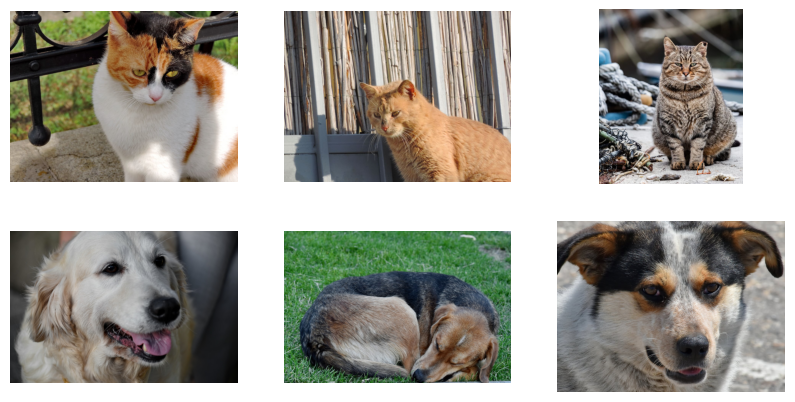

In [18]:
from matplotlib import pyplot as plt
from PIL import Image

fig = plt.figure(figsize=(10, 5))
for i, file in enumerate(path_files):
    img = Image.open(file)
    ax = fig.add_subplot(2, 3, i+1)
    print("Image shape: ", np.array(img).shape)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.imshow(img)
    plt.axis('off')
plt.show()



In [19]:
import os

labels = [1 if 'dog' in os.path.basename(path) else 0 for path in path_files]
labels

[0, 0, 0, 1, 1, 1]

In [20]:
# transform the data
from torchvision.transforms import transforms

IMAGE_WIDTH, IMAGE_HEIGHT = 120, 80
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((IMAGE_HEIGHT, IMAGE_WIDTH)),
])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.000551827..1.0000002].


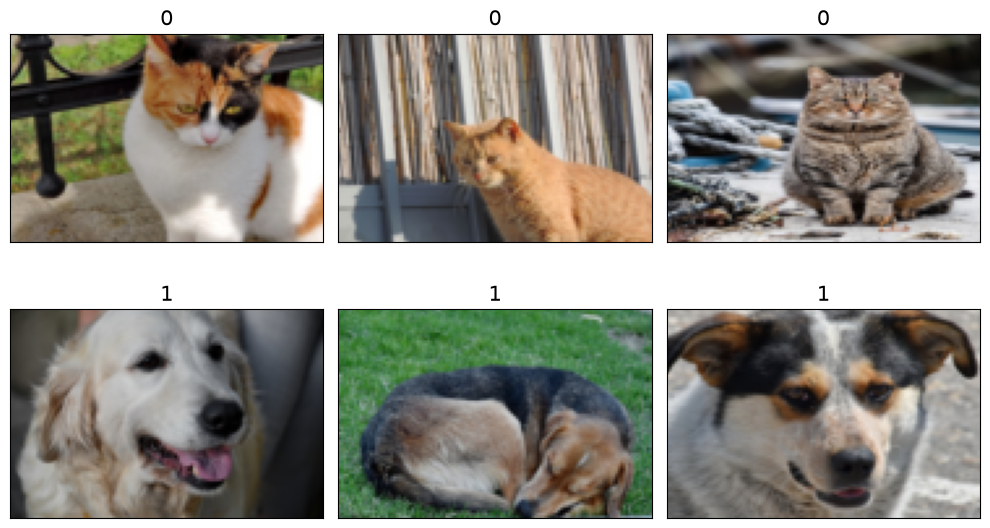

In [21]:
# create a dataset
class ImageDataset(Dataset):
    def __init__(self, file_list, labels, transform=None):
        self.file_list = file_list
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.file_list)
    
    def __getitem__(self, idx):
        img = Image.open(self.file_list[idx])
        if self.transform is not None:
            img = self.transform(img)
        label = self.labels[idx]
        return img, label

image_dataset = ImageDataset(path_files, labels, transform=transform)
fig = plt.figure(figsize=(10, 6))
for i, example in enumerate(image_dataset):
    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(example[0].numpy().transpose((1, 2, 0)))
    ax.set_title(f'{example[1]}', size=15)

plt.tight_layout()
plt.show()

Download and work with CelebA dataset from torchvision

In [22]:
import torchvision

image_dir = "./"

celeba_dataset = torchvision.datasets.CelebA(
    root=image_dir,
    split="train",
    target_type="attr",
    download=True
)

In [23]:
isinstance(celeba_dataset, torch.utils.data.Dataset)

True

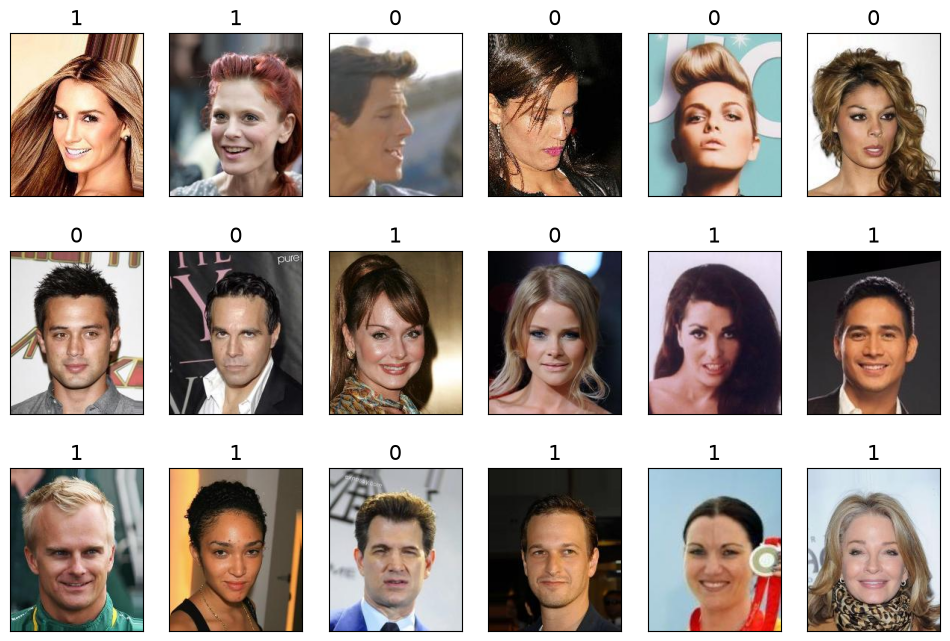

In [24]:
# take a look at image and 31st label(Similing)
from itertools import islice
fig = plt.figure(figsize=(12, 8))

for i, (image, attributes) in islice(enumerate(celeba_dataset), 18):
    ax = fig.add_subplot(3, 6, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(image)
    ax.set_title(f'{attributes[31]}', size=15)
plt.show()

Build a Linear Regression Model with PyTorch

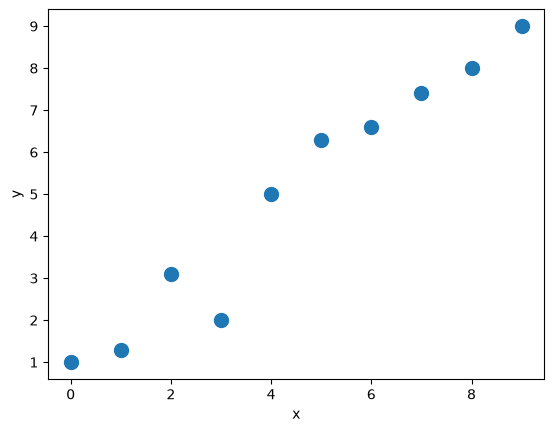

In [25]:
X_train = np.arange(10, dtype='float32').reshape((10, 1))
y_train = np.array([1.0, 1.3, 3.1, 2.0, 5.0,
6.3, 6.6,7.4, 8.0,
9.0], dtype='float32')
plt.plot(X_train, y_train, 'o', markersize=10)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [26]:
# transform the data for pytorch model
from torch.utils.data import TensorDataset

X_train_norm = (X_train - np.mean(X_train)) / np.std(X_train)
X_train_norm = torch.from_numpy(X_train_norm)
y_train = torch.from_numpy(y_train)

dataset = TensorDataset(X_train_norm, y_train)
batch_size = 1
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [27]:
# simple linear regression model

torch.manual_seed(1)
weight = torch.randn(1, requires_grad=True)
bias = torch.zeros(1, requires_grad=True)

def model(xb):
    return xb @ weight + bias

def loss_fn(input, target):
    return (input - target).pow(2).mean()

In [28]:
num_epochs = 200
learning_rate = 0.001
log_epochs = 10

for epoch in range(num_epochs):
    for xb, yb in data_loader:
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()

        with torch.no_grad():
            weight -= weight.grad * learning_rate
            bias -= bias.grad * learning_rate
            weight.grad.zero_()
            bias.grad.zero_()
        
    if epoch % log_epochs == 0:
        print(f'epoch {epoch} loss: {loss.item():.4f}')

print('Final Parameters:', weight, bias)

epoch 0 loss: 45.0782
epoch 10 loss: 26.4366
epoch 20 loss: 1.5918
epoch 30 loss: 14.1307
epoch 40 loss: 11.6038
epoch 50 loss: 6.3084
epoch 60 loss: 0.6349
epoch 70 loss: 3.1374
epoch 80 loss: 1.9999
epoch 90 loss: 0.3133
epoch 100 loss: 0.7653
epoch 110 loss: 1.0039
epoch 120 loss: 0.0235
epoch 130 loss: 0.5176
epoch 140 loss: 0.0759
epoch 150 loss: 1.8789
epoch 160 loss: 0.0008
epoch 170 loss: 0.0866
epoch 180 loss: 0.0646
epoch 190 loss: 0.0011
Final Parameters: tensor([2.6696], requires_grad=True) tensor([4.8797], requires_grad=True)


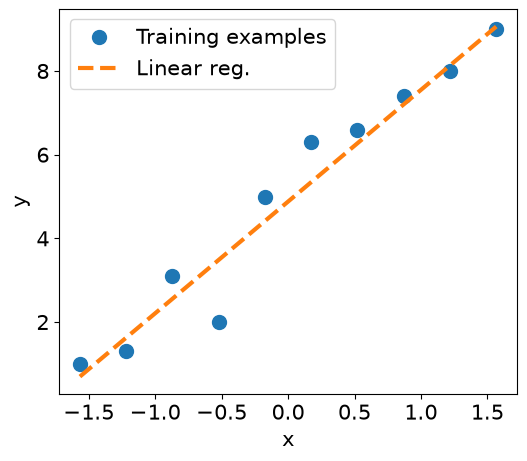

In [29]:
X_test = np.linspace(0, 9, num=100, dtype='float32').reshape(-1, 1)
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm)
y_pred = model(X_test_norm).detach().numpy()
fig = plt.figure(figsize=(13, 5))
ax = fig.add_subplot(1, 2, 1)
plt.plot(X_train_norm, y_train, 'o', markersize=10)
plt.plot(X_test_norm, y_pred, '--', lw=3)
plt.legend(['Training examples', 'Linear reg.'], fontsize=15)
ax.set_xlabel('x', size=15)
ax.set_ylabel('y', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.show()

In [30]:
# linear regression with pytorch module
import torch.nn as nn

loss = nn.MSELoss(reduction="mean")
input_dim = 1
output_dim=1
model = nn.Linear(input_dim, output_dim)
optim = torch.optim.SGD(model.parameters(), lr=0.001)

In [31]:
for epoch in range(num_epochs):
    for xb, y_b in data_loader:
        pred = model(xb)
        loss = loss_fn(pred, y_b)
        loss.backward()
        optim.step()
        optim.zero_grad()
        
    if epoch % log_epochs == 0:
        print(f'epoch {epoch} loss: {loss.item():.4f}')

print('Final Parameters:', model.weight.item(), model.bias.item())

epoch 0 loss: 24.6684
epoch 10 loss: 29.1377
epoch 20 loss: 20.9207
epoch 30 loss: 0.1257
epoch 40 loss: 12.4922
epoch 50 loss: 1.7845
epoch 60 loss: 7.6425
epoch 70 loss: 2.5606
epoch 80 loss: 0.0157
epoch 90 loss: 0.7548
epoch 100 loss: 0.8412
epoch 110 loss: 0.4923
epoch 120 loss: 0.0823
epoch 130 loss: 0.0794
epoch 140 loss: 0.0891
epoch 150 loss: 0.0973
epoch 160 loss: 0.1043
epoch 170 loss: 0.1103
epoch 180 loss: 0.0009
epoch 190 loss: 0.0764
Final Parameters: 2.6496422290802 4.87706995010376


Build the standard neural network in PyTorch and work with Iris Dataset

In [32]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [34]:
# process the data for pytorch model
X_train_norm = (X_train - np.mean(X_train, axis=0)) / np.std(X_train, axis=0)
X_train_norm = torch.from_numpy(X_train_norm).float()
y_train = torch.from_numpy(y_train).long()

X_test_norm = (X_test - np.mean(X_train, axis=0)) / np.std(X_train, axis=0)
X_test_norm = torch.from_numpy(X_test_norm).float()
y_test = torch.from_numpy(y_test).long()

batch_size = 2
train_ds = TensorDataset(X_train_norm, y_train)
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

In [35]:
# simple nn
class Model(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        x = self.layer1(x)
        x = torch.sigmoid(x)
        x = self.layer2(x)
        x = torch.softmax(x, dim=1)
        return x

In [36]:
input_size = X_train_norm.shape[1]
hidden_size = 16
output_size = 3

model = Model(input_size, hidden_size, output_size)

In [37]:
learning_rate = 0.001
num_epochs = 100
log_epochs = 10

loss_fn = nn.CrossEntropyLoss()
optim = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [38]:
loss_history = [0]*num_epochs
accuracy_history = [0]*num_epochs

for epoch in range(num_epochs):
    for xb, yb in train_dl:
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optim.step()
        optim.zero_grad()
        
        loss_history[epoch] += loss.item()*yb.size(0)
        accuracy_history[epoch] += (pred.argmax(dim=1) == yb).sum().item()
        
    loss_history[epoch] /= len(train_ds)
    accuracy_history[epoch] /= len(train_ds)
    
   

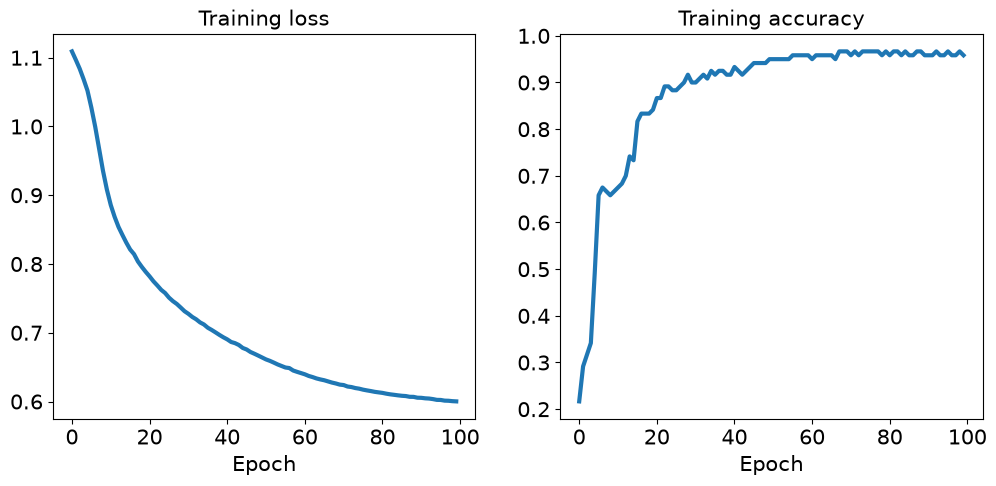

In [39]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1)

ax.plot(loss_history, lw=3)
ax.set_title('Training loss', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax = fig.add_subplot(1, 2, 2)
ax.plot(accuracy_history, lw=3)
ax.set_title('Training accuracy', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.show()

In [40]:
# testing/eval
pred_test = model(X_test_norm)
correct = (torch.argmax(pred_test, dim=1) == y_test).float()
accuracy = correct.mean()
print(f'Test Acc.: {accuracy:.4f}')

Test Acc.: 0.9667


In [41]:
path='iris_classifier.pt'
torch.save(model, path)

In [42]:
model_new = torch.load(path, weights_only=False)
model_new.eval()

Model(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=3, bias=True)
)

In [43]:
pred_test = model_new(X_test_norm)
correct = (torch.argmax(pred_test, dim=1) == y_test).float()
accuracy = correct.mean()
print(f'Test Acc.: {accuracy:.4f}')

Test Acc.: 0.9667


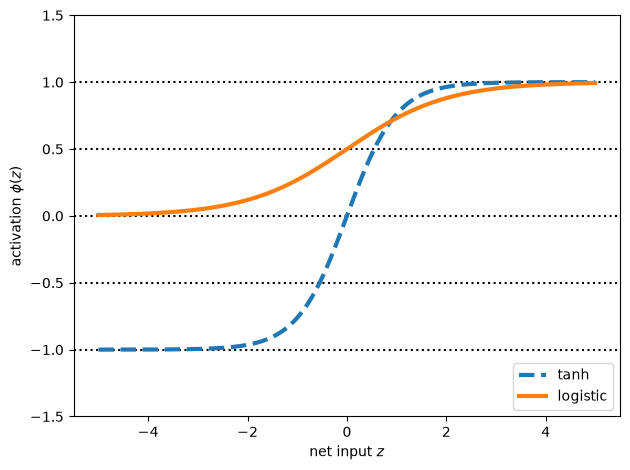

In [44]:
# activation function: tanh, sigmoid

def tanh(z):
    e_m = np.exp(z)
    e_p = np.exp(-z)

    return (e_m-e_p) / (e_m+e_p)

def logistic(z):
    return 1 / (1.0 + np.exp(-z))

z = np.arange(-5, 5, 0.005)
log_act = logistic(z)
tanh_act = tanh(z)
plt.ylim([-1.5, 1.5])
plt.xlabel('net input $z$')
plt.ylabel('activation $\phi(z)$')
plt.axhline(1, color='black', linestyle=':')
plt.axhline(0.5, color='black', linestyle=':')
plt.axhline(0, color='black', linestyle=':')
plt.axhline(-0.5, color='black', linestyle=':')
plt.axhline(-1, color='black', linestyle=':')
plt.plot(z, tanh_act,
    linewidth=3, linestyle='--',
    label='tanh')
plt.plot(z, log_act,
    linewidth=3,
    label='logistic')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [45]:
#activation with torch
print(torch.sigmoid(torch.from_numpy(z)))
print(torch.relu(torch.from_numpy(z)))

tensor([0.0067, 0.0067, 0.0068,  ..., 0.9932, 0.9932, 0.9933],
       dtype=torch.float64)
tensor([0.0000, 0.0000, 0.0000,  ..., 4.9850, 4.9900, 4.9950],
       dtype=torch.float64)
